In [1]:
%load_ext autoreload
%autoreload 2

# Interpret Handwritten Numbers from Acta Crops

Pipeline:
1. Load crop PNGs saved by notebook 1.02
2. Split each crop into 3 digit boxes (hundreds / tens / units)
3. Run EasyOCR on each box to read the digit
4. Assemble the full number and compare across actas

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

from elecc_colombia.config import INTERIM_DATA_DIR

CROPS_DIR = INTERIM_DATA_DIR / "crops"

# List all crop PNGs grouped by acta
crop_files = sorted(CROPS_DIR.rglob("*.png"))
#select third file
#sample_path = crop_files[2]
print(f"Found {len(crop_files)} crop images across {len(set(p.parent for p in crop_files))} actas")
crop_files[6:11]

Found 27 crop images across 3 actas


[PosixPath('/Users/mmh54/Documents/github/escrutinio-elecciones-col/data/interim/crops/ATLANTICO/004_BARANOA_ZONA_01_01_ESCUELA_NORMAL_SUPERIOR_SANTA_ANA_ENSSA_mesa_008/VOTOS_EN_BLANCO.png'),
 PosixPath('/Users/mmh54/Documents/github/escrutinio-elecciones-col/data/interim/crops/ATLANTICO/004_BARANOA_ZONA_01_01_ESCUELA_NORMAL_SUPERIOR_SANTA_ANA_ENSSA_mesa_008/VOTOS_NO_MARCADOS.png'),
 PosixPath('/Users/mmh54/Documents/github/escrutinio-elecciones-col/data/interim/crops/ATLANTICO/004_BARANOA_ZONA_01_01_ESCUELA_NORMAL_SUPERIOR_SANTA_ANA_ENSSA_mesa_008/VOTOS_NULOS.png'),
 PosixPath('/Users/mmh54/Documents/github/escrutinio-elecciones-col/data/interim/crops/ATLANTICO/004_BARANOA_ZONA_01_01_ESCUELA_NORMAL_SUPERIOR_SANTA_ANA_ENSSA_mesa_009/ABELARDO_DE_LA_ESPRIELLA.png'),
 PosixPath('/Users/mmh54/Documents/github/escrutinio-elecciones-col/data/interim/crops/ATLANTICO/004_BARANOA_ZONA_01_01_ESCUELA_NORMAL_SUPERIOR_SANTA_ANA_ENSSA_mesa_009/IVAN_CEPEDA_CASTRO.png')]

## 1 — Inspect a single crop

Label : IVAN_CEPEDA_CASTRO
Acta  : 004_BARANOA_ZONA_01_03_FRANCISCO_JOSE_DE_CALDAS_SD_EL_CAMPESINO_mesa_005
Size  : 868w × 1188h px


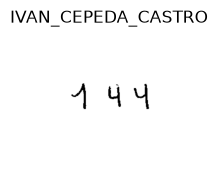

In [18]:
# Pick one crop to work with — change the index or path as needed
sample_path = crop_files[19]
print(f"Label : {sample_path.stem}")
print(f"Acta  : {sample_path.parent.name}")

img = np.array(Image.open(sample_path).convert("RGB"))
print(f"Size  : {img.shape[1]}w × {img.shape[0]}h px")

plt.figure(figsize=(10, 2))
plt.imshow(img)
plt.axis("off")
plt.title(sample_path.stem)
plt.tight_layout()
plt.show()

## 2 — Split crop into digit boxes

Each number has at most 3 digits (hundreds / tens / units).
Split the crop width into 3 equal columns and display them side by side.

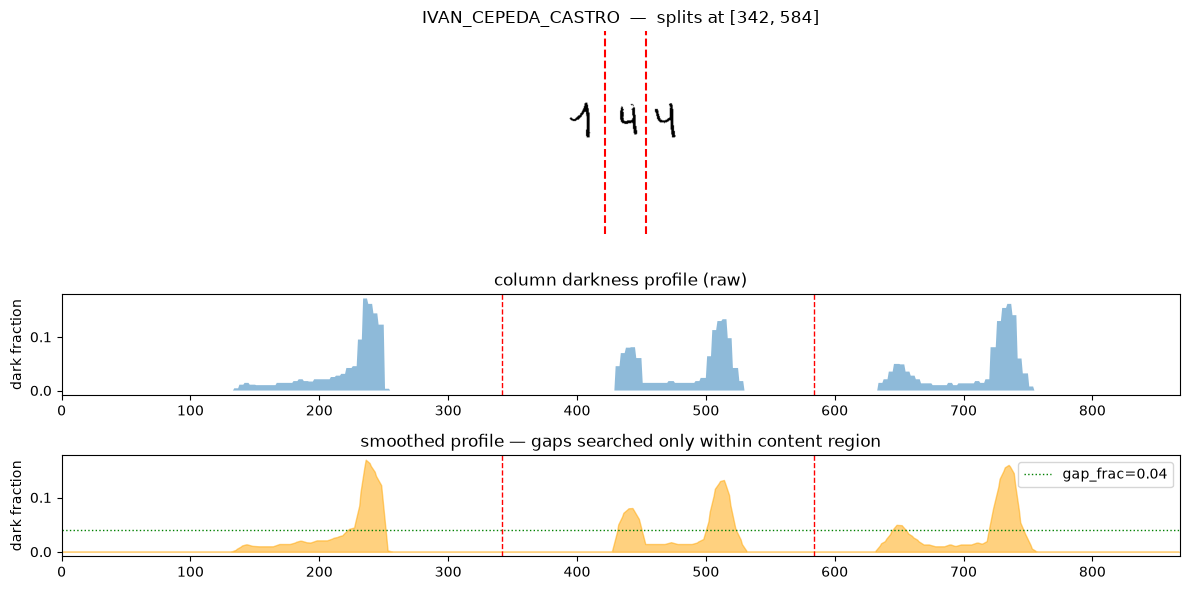

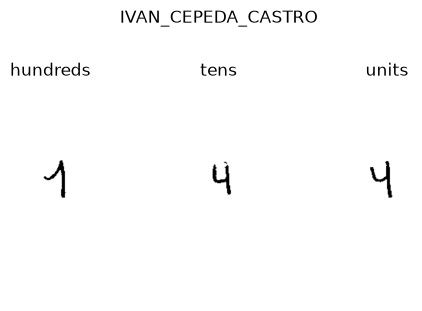

In [19]:
def strip_border_lines(
    img,
    dark_threshold=80,
    dark_fraction=0.6,
    search_margin_frac=0.25,
):
    """Remove full-height vertical border lines from left and right edges."""
    gray = img.mean(axis=2) if img.ndim == 3 else img.astype(float)
    h, w = gray.shape
    margin = max(1, int(w * search_margin_frac))
    col_dark = (gray < dark_threshold).sum(axis=0) / h

    left = 0
    for x in range(margin):
        if col_dark[x] >= dark_fraction:
            left = x + 1

    right = w
    for x in range(w - margin, w):
        if col_dark[x] >= dark_fraction:
            right = x
            break

    if left >= right:
        return img
    return img[:, left:right]


def split_digit_boxes(
    img,
    n=3,
    dark_threshold=80,
    gap_frac=0.04,
    smooth_px=5,
    content_frac=0.01,
):
    """Split a crop into n digit boxes using whitespace gaps between digits.

    Ignores leading and trailing white space by first detecting the content
    region (columns with at least content_frac dark pixels). Gap search is
    restricted to that region, so large empty margins do not steal split
    points from the real gaps between digits.

    Parameters
    ----------
    gap_frac : float
        Threshold below which a column is considered a gap (< 4% dark pixels).
    smooth_px : int
        Smoothing window to merge thin ink strokes before gap detection.
    content_frac : float
        Minimum dark-pixel fraction for a column to count as "has content".
    """
    img = strip_border_lines(img)
    gray = img.mean(axis=2) if img.ndim == 3 else img.astype(float)
    h, w = gray.shape

    col_dark = (gray < dark_threshold).sum(axis=0) / h

    # Detect content region — ignore leading/trailing white space
    content_cols = np.where(col_dark >= content_frac)[0]
    if len(content_cols) == 0:
        edges = [int(i * w / n) for i in range(n + 1)]
        return [img[:, edges[i]:edges[i+1]] for i in range(n)], col_dark, col_dark, []
    content_left  = int(content_cols[0])
    content_right = int(content_cols[-1]) + 1

    # Smooth profile to avoid splitting inside a digit stroke
    if smooth_px > 1:
        kernel = np.ones(smooth_px) / smooth_px
        col_dark_smooth = np.convolve(col_dark, kernel, mode="same")
    else:
        col_dark_smooth = col_dark.copy()

    # Search for gaps only within the content region
    is_gap = col_dark_smooth < gap_frac
    is_gap[:content_left]  = False   # ignore leading white space
    is_gap[content_right:] = False   # ignore trailing white space

    # Find contiguous gap regions
    gap_regions = []
    in_gap = False
    g_start = 0
    for x in range(w):
        if is_gap[x] and not in_gap:
            g_start = x
            in_gap = True
        elif not is_gap[x] and in_gap:
            gap_regions.append((g_start, x))
            in_gap = False
    if in_gap:
        gap_regions.append((g_start, content_right))

    # Pick the n-1 widest gaps as split points
    gap_regions.sort(key=lambda g: -(g[1] - g[0]))
    best = sorted(gap_regions[:n - 1], key=lambda g: g[0])
    splits = [int((g[0] + g[1]) / 2) for g in best]

    # Fall back to equal spacing within the content region for missing splits
    content_w = content_right - content_left
    while len(splits) < n - 1:
        equal = [content_left + int(content_w * (i + 1) / n) for i in range(n - 1)]
        splits = sorted(set(splits) | set(equal))[:n - 1]

    boundaries = [0] + splits + [w]
    return [img[:, boundaries[i]:boundaries[i+1]] for i in range(n)], col_dark, col_dark_smooth, splits


# ── visualise ────────────────────────────────────────────────────────────────
img_clean = strip_border_lines(img)
boxes, col_dark, col_dark_smooth, splits = split_digit_boxes(img)

w = img_clean.shape[1]
fig, axes = plt.subplots(3, 1, figsize=(12, 6), gridspec_kw={"height_ratios": [2, 1, 1]})

axes[0].imshow(img_clean)
for s in splits:
    axes[0].axvline(s, color="red", linewidth=1.5, linestyle="--")
axes[0].set_title(f"{sample_path.stem}  —  splits at {splits}")
axes[0].axis("off")

axes[1].fill_between(range(w), col_dark, alpha=0.5)
for s in splits:
    axes[1].axvline(s, color="red", linewidth=1, linestyle="--")
axes[1].set_xlim(0, w)
axes[1].set_ylabel("dark fraction")
axes[1].set_title("column darkness profile (raw)")

axes[2].fill_between(range(w), col_dark_smooth, alpha=0.5, color="orange")
axes[2].axhline(0.04, color="green", linewidth=1, linestyle=":", label="gap_frac=0.04")
for s in splits:
    axes[2].axvline(s, color="red", linewidth=1, linestyle="--")
axes[2].set_xlim(0, w)
axes[2].set_ylabel("dark fraction")
axes[2].set_title("smoothed profile — gaps searched only within content region")
axes[2].legend()

plt.tight_layout()
plt.show()

positions = ["hundreds", "tens", "units"]
fig, ax_row = plt.subplots(1, 3, figsize=(6, 3))
for ax, box, pos in zip(ax_row, boxes, positions):
    ax.imshow(box)
    ax.set_title(pos)
    ax.axis("off")
plt.suptitle(sample_path.stem, y=1.02)
plt.tight_layout()
plt.show()

## 3 — Read each digit box with EasyOCR

Using CPU. Note: This module is much faster with a GPU.


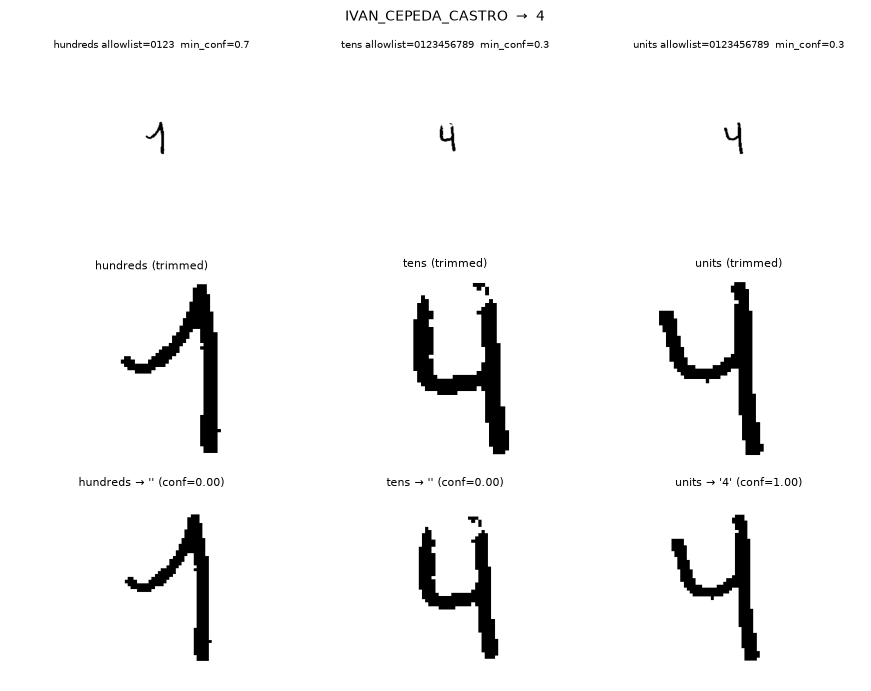

In [21]:
import easyocr
from PIL import Image as PILImage

ocr = easyocr.Reader(["en"], gpu=False)

# Per-position allowlists and confidence thresholds.
# Hundreds: only 0-3 are valid; marks (*, ., -) are ignored by the allowlist.
#           Higher min_confidence because 1 can look like 7 when the stroke is extended.
# Tens / Units: any digit; lower threshold is fine.
POSITION_ALLOWLISTS      = ["0123",       "0123456789", "0123456789"]
POSITION_MIN_CONFIDENCE  = [0.7,           0.3,           0.3]
#                           ^^^^ tune this if hundreds are still wrong


def trim_vertical_whitespace(img, dark_threshold=80, content_frac=0.01, pad_px=8):
    """Crop top and bottom white space, keeping only rows that contain ink."""
    gray = img.mean(axis=2) if img.ndim == 3 else img.astype(float)
    h, w = gray.shape
    row_dark = (gray < dark_threshold).sum(axis=1) / w

    content_rows = np.where(row_dark >= content_frac)[0]
    if len(content_rows) == 0:
        return img

    top    = max(0, int(content_rows[0])  - pad_px)
    bottom = min(h, int(content_rows[-1]) + 1 + pad_px)
    return img[top:bottom, :]


def preprocess_digit_box(box, pad=20, min_dim=80):
    """Trim whitespace → binarize → pad → upscale → RGB."""
    box = trim_vertical_whitespace(box)
    gray = np.array(PILImage.fromarray(box).convert("L"))
    bg = np.percentile(gray, 90)
    fg = np.percentile(gray, 10)
    thresh = (bg + fg) / 2
    binary = np.where(gray < thresh, 0, 255).astype(np.uint8)
    binary = np.pad(binary, pad_width=pad, constant_values=255)
    h, w = binary.shape
    if min(h, w) < min_dim:
        scale = min_dim / min(h, w)
        pil_bin = PILImage.fromarray(binary)
        pil_bin = pil_bin.resize((int(w * scale), int(h * scale)), PILImage.LANCZOS)
        binary = np.array(pil_bin)
    return np.stack([binary, binary, binary], axis=2)


def read_digit_box(box, allowlist="0123456789", min_confidence=0.3) -> tuple[str, float]:
    """Preprocess and run EasyOCR.

    Returns (digit, confidence).
    digit is '?' when the best match is below min_confidence — flag for manual review.
    digit is ''  when nothing was detected at all.
    """
    processed = preprocess_digit_box(box)
    results = ocr.readtext(processed, allowlist=allowlist)  # detail=1 — returns (bbox, text, conf)
    for _bbox, text, conf in results:
        digits = "".join(c for c in text if c.isdigit())
        if digits:
            digit = digits[0]
            return (digit, conf) if conf >= min_confidence else ("?", conf)
    return "", 0.0


def read_number_from_crop(img) -> tuple[str, list[float]]:
    """Strip borders, split, read each box. Returns (number_string, confidences).

    number_string contains '?' in place of any digit whose confidence was too low.
    Caller can detect uncertainty with '?' in number_string.
    """
    boxes, *_ = split_digit_boxes(img)
    pairs  = [read_digit_box(b, al, mc) for b, al, mc in zip(boxes, POSITION_ALLOWLISTS, POSITION_MIN_CONFIDENCE)]
    digits = [d for d, _ in pairs]
    confs  = [c for _, c in pairs]
    number = "".join(digits).lstrip("0") or "0"
    return number, confs


# ── test on sample ────────────────────────────────────────────────────────────
boxes, *_ = split_digit_boxes(img)
positions = ["hundreds", "tens", "units"]

fig, axes = plt.subplots(3, 3, figsize=(9, 7))
for col, (box, pos, al, mc) in enumerate(zip(boxes, positions, POSITION_ALLOWLISTS, POSITION_MIN_CONFIDENCE)):
    trimmed   = trim_vertical_whitespace(box)
    processed = preprocess_digit_box(box)
    digit, conf = read_digit_box(box, al, mc)

    color = "red" if digit == "?" else "black"
    axes[0, col].imshow(box)
    axes[0, col].set_title(f"{pos} allowlist={al}  min_conf={mc}", fontsize=7)
    axes[0, col].axis("off")

    axes[1, col].imshow(trimmed)
    axes[1, col].set_title(f"{pos} (trimmed)", fontsize=8)
    axes[1, col].axis("off")

    axes[2, col].imshow(processed)
    label = f"{pos} → '{digit}' (conf={conf:.2f})"
    axes[2, col].set_title(label, fontsize=8, color=color)
    axes[2, col].axis("off")

number, confs = read_number_from_crop(img)
uncertain = "?" in number
fig.suptitle(
    f"{sample_path.stem}  →  {number}" + ("  ⚠ uncertain" if uncertain else ""),
    fontsize=10,
    color="red" if uncertain else "black",
)
plt.tight_layout()
plt.show()

## 4 — Visualise boxes alongside OCR result for one acta

Useful for tuning: shows the 3 boxes and the digit read from each.

Acta: 004_BARANOA_ZONA_01_01_ESCUELA_NORMAL_SUPERIOR_SANTA_ANA_ENSSA_mesa_008



ValueError: Invalid input type. Supporting format = string(file path or url), bytes, numpy array

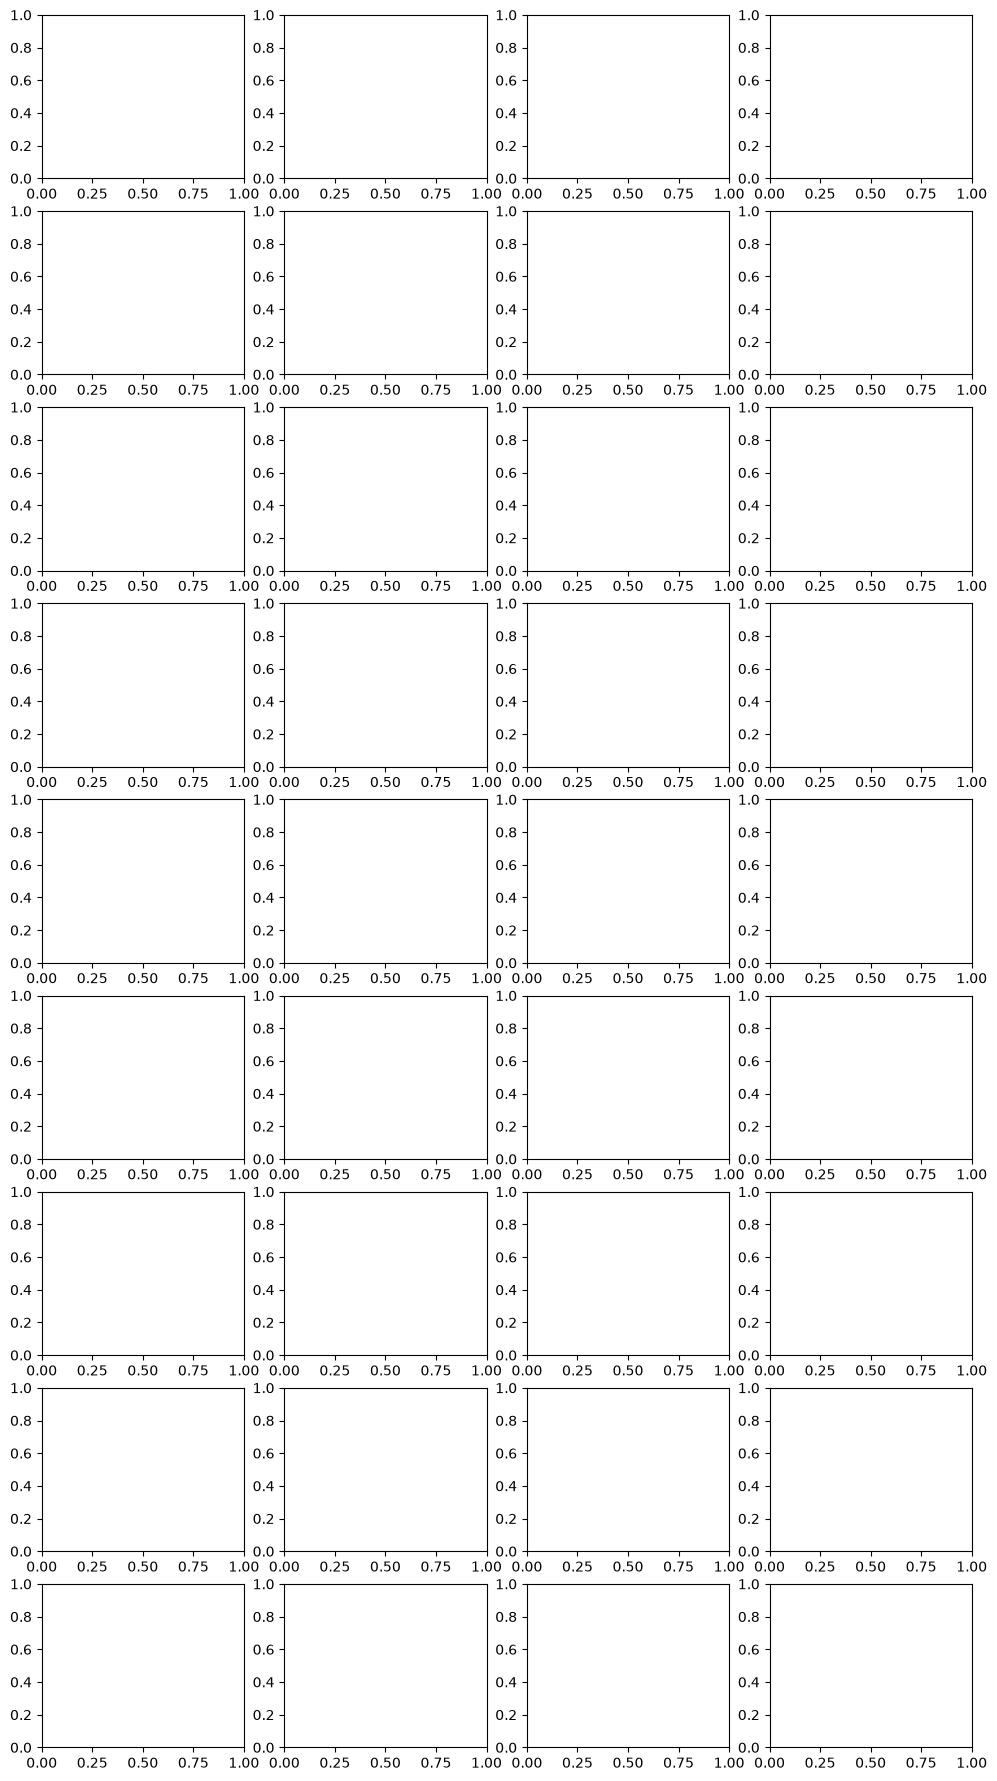

In [9]:
# Pick one acta folder to inspect all its labels at once
acta_dirs = sorted({p.parent for p in crop_files})
acta_dir = acta_dirs[0]   # change index to inspect a different acta
print(f"Acta: {acta_dir.name}\n")

acta_crops = sorted(acta_dir.glob("*.png"))
fig, axes = plt.subplots(len(acta_crops), 4, figsize=(12, 2.5 * len(acta_crops)))
if len(acta_crops) == 1:
    axes = [axes]

for row_axes, crop_path in zip(axes, acta_crops):
    crop_img = np.array(Image.open(crop_path).convert("RGB"))
    boxes = split_digit_boxes(crop_img)
    digits = [read_digit_box(b) for b in boxes]
    number = "".join(digits).lstrip("0") or "0"

    row_axes[0].imshow(crop_img)
    row_axes[0].set_title(f"{crop_path.stem}\n→ {number}", fontsize=8)
    row_axes[0].axis("off")

    for ax, box, d, pos in zip(row_axes[1:], boxes, digits, ["H", "T", "U"]):
        ax.imshow(box)
        ax.set_title(f"{pos}: '{d}'", fontsize=8)
        ax.axis("off")

plt.tight_layout()
plt.show()

## 5 — Batch all crops → results table

In [ ]:
import pandas as pd
from tqdm.notebook import tqdm

rows = []
for crop_path in tqdm(crop_files, desc="Reading crops"):
    crop_img = np.array(Image.open(crop_path).convert("RGB"))
    number = read_number_from_crop(crop_img)
    rows.append({
        "DEPARTAMENTO": crop_path.parent.parent.name,
        "ACTA":         crop_path.parent.name,
        "LABEL":        crop_path.stem,
        "VALUE":        number,
    })

results_df = pd.DataFrame(rows)
results_df